# Motion Classification Analysis and Performance Study
This notebook analyzes the performance, precision, and accuracy of the 4 motion classification methods defined in `IndependentMotionClassifier`.
We generate synthetic trajectories with realistic IMU noise for three modes:
1. **Linear Motion** (Walking in a straight line)
2. **Circular/Curvilinear Motion** (Walking in a circle)
3. **Random Walk** (Erratic, chaotic movements)

We then process the data through the sliding windows of our four algorithms.


In [1]:
import sys
import os
sys.path.insert(0, os.path.abspath('.'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import deque
import navpy

from src.core.uwb.imu import IMUSimulator, IMUData
from src.core.motion.motion_classifier import IndependentMotionClassifier
from src.core.uwb.uwb_devices import Position

sns.set_theme(style="whitegrid")


## 1. Simulation Environment & Data Generation
We use the `IMUSimulator` from the PULSE physics core to add Gaussian white noise and bias instability to ideal trajectory kinematics.


In [2]:
class TagMock:
    def __init__(self):
        self.imu_data = IMUData(max_samples=20000)
        self.velocity = type('Vel', (), {'x':0.0, 'y':0.0, 'z':0.0})()
        self.angular_velocity = 0.0

def generate_motion_data(motion_type, duration=60, dt=0.01):
    sim = IMUSimulator(sample_rate=int(1/dt), acc_noise_std=0.05, gyro_noise_std=0.01)
    tag = TagMock()
    
    times = np.arange(0, duration, dt)
    history = []
    
    pos = Position(0, 0, 0)
    yaw = 0.0
    w = 0.0
    
    # Smooth transitions for Random Walk
    random_w_target = 0.0
    
    for t in times:
        if motion_type == "Linear Motion":
            v_mag = 1.2
            w = 0.0
            accel_world = np.array([0., 0., 0.])
            
        elif motion_type == "Circular/Curvilinear Motion":
            v_mag = 1.0
            w = 0.3
            # Centripetal acceleration
            accel_world = np.cross([0, 0, w], [v_mag * np.cos(yaw), v_mag * np.sin(yaw), 0])
            
        elif motion_type == "Random Walk":
            # Brownian walk for angular velocity
            if np.random.rand() < 0.05: # change target every ~0.2s
                random_w_target = np.random.normal(0, 1.5)
            w += (random_w_target - w) * 0.1
            v_mag = max(0.1, 1.0 + np.random.normal(0, 0.2))
            accel_world = np.random.normal(0, 0.5, 3)
        
        yaw += w * dt
        vx = v_mag * np.cos(yaw)
        vy = v_mag * np.sin(yaw)
        
        tag.velocity.x = vx
        tag.velocity.y = vy
        tag.angular_velocity = w
        
        pos.x += vx * dt
        pos.y += vy * dt
        
        vel_world = np.array([vx, vy, 0.])
        angular_vel_world = np.array([0, 0, w])
        
        # Add physics noise using the simulator
        acc_meas, gyro_meas = sim.generate_imu_data(
            pos, yaw, dt, velocity=vel_world, acceleration=accel_world, angular_velocity=angular_vel_world
        )
        
        tag.imu_data.add_measurement(t, acc_meas[0], acc_meas[1], acc_meas[2], gyro_meas[0], gyro_meas[1], gyro_meas[2])
        
        history.append({
            't': t,
            'pos_x': pos.x,
            'pos_y': pos.y,
            'yaw': yaw,
            'vx': vx,
            'vy': vy,
            'w': w,
            'accel': acc_meas,
            'gyro': gyro_meas
        })
        
    return pd.DataFrame(history)

# Generate datasets
print("Generating trajectories...")
df_linear = generate_motion_data("Linear Motion")
df_circular = generate_motion_data("Circular/Curvilinear Motion")
df_random = generate_motion_data("Random Walk")
print("Done!")


Generating trajectories...


Done!


### Trajectory Visualization
Let's verify the ground truth trajectories in the NED (North-East-Down) frame.


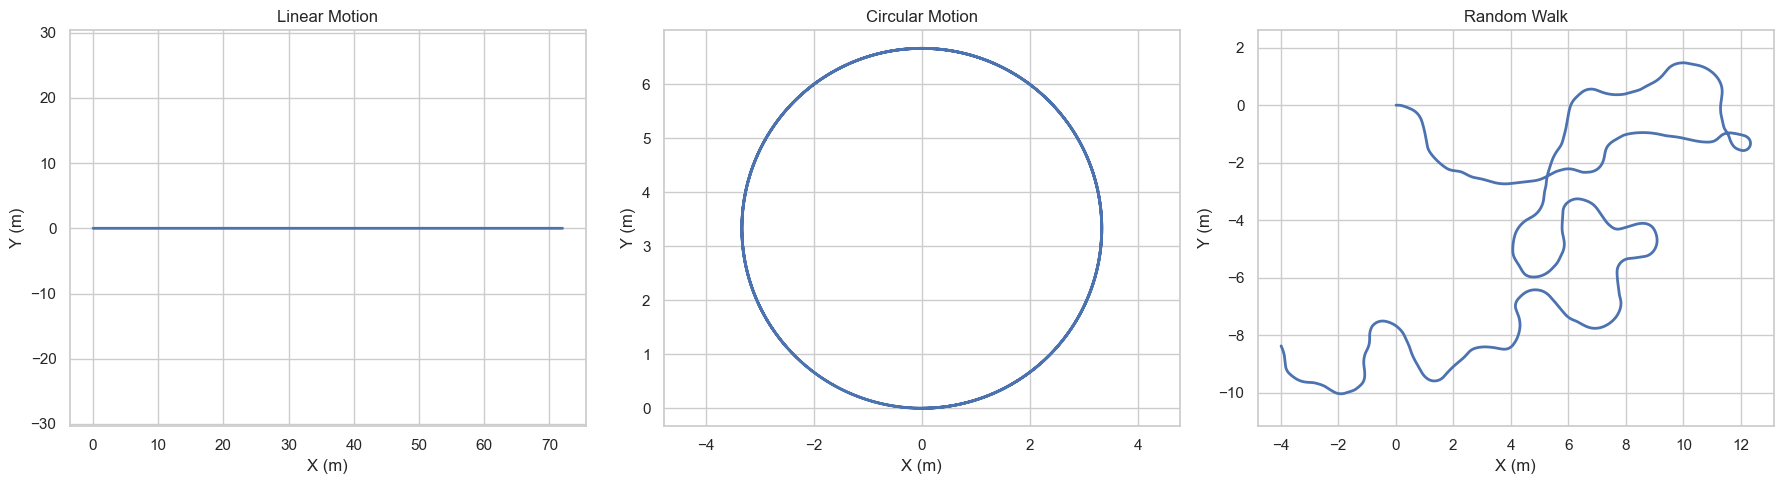

In [3]:
fig, ax = plt.subplots(1, 3, figsize=(18, 5))
datasets = [("Linear Motion", df_linear), ("Circular Motion", df_circular), ("Random Walk", df_random)]

for i, (title, df) in enumerate(datasets):
    ax[i].plot(df['pos_x'], df['pos_y'], lw=2)
    ax[i].set_title(title)
    ax[i].set_xlabel("X (m)")
    ax[i].set_ylabel("Y (m)")
    ax[i].axis('equal')

plt.tight_layout()
plt.show()


## 2. Algorithm Testing Pipeline
We'll stream the generated IMU data point-by-point into the `IndependentMotionClassifier` methods and log the real-time predictions.


In [4]:
def run_classification_benchmark(df, true_label):
    classifier = IndependentMotionClassifier()
    classifier.initialize()
    
    preds = []
    
    for i in range(len(df)):
        accel = df.iloc[i]['accel']
        gyro = df.iloc[i]['gyro']
        t = df.iloc[i]['t']
        
        classifier.accel_window.append(accel)
        classifier.gyro_window.append(gyro)
        
        # Start classifying once window is full
        if len(classifier.accel_window) == classifier.window_size:
            vel = np.array([df.iloc[i]['vx'], df.iloc[i]['vy'], 0.0])
            
            m1 = classifier.method_1_gyro_kinematic(classifier.gyro_window)
            m2 = classifier.method_2_pca(classifier.accel_window)
            m3 = classifier.method_3_centripetal(accel, gyro, vel)
            m4 = classifier.method_4_variance_zcr(classifier.accel_window)
            
            preds.append({
                't': t,
                'True': true_label,
                'M1': m1,
                'M2': m2,
                'M3': m3,
                'M4': m4
            })
            
    return pd.DataFrame(preds)

print("Running benchmarks...")
res_linear = run_classification_benchmark(df_linear, "Linear Motion")
res_circular = run_classification_benchmark(df_circular, "Circular/Curvilinear Motion")
res_random = run_classification_benchmark(df_random, "Random Walk")

results_df = pd.concat([res_linear, res_circular, res_random], ignore_index=True)
print("Benchmarking Complete!")


Running benchmarks...


Benchmarking Complete!


## 3. Precision & Performance Analysis
We will analyze the accuracy of each method across the dataset.


In [5]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

methods = ['M1', 'M2', 'M3', 'M4']
method_names = ['Gyro Kinematic', 'PCA', 'Centripetal', 'Variance/ZCR']

accuracy_dict = {}

print("=========================================================")
print("             OVERALL ALGORITHM PRECISION                 ")
print("=========================================================")

for method, name in zip(methods, method_names):
    y_true = results_df['True']
    y_pred = results_df[method]
    
    # Handle "Unknown" class (usually warmup frames, but here window is full)
    acc = accuracy_score(y_true, y_pred)
    accuracy_dict[name] = acc * 100
    
    print(f"{name:20s}: {acc*100:.2f}% Accuracy")

print("=========================================================")


             OVERALL ALGORITHM PRECISION                 
Gyro Kinematic      : 85.11% Accuracy
PCA                 : 33.33% Accuracy
Centripetal         : 74.08% Accuracy
Variance/ZCR        : 33.33% Accuracy


C:\Users\tmoussa\AppData\Local\Temp\ipykernel_36544\2006322251.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(accuracy_dict.keys()), y=list(accuracy_dict.values()), palette='viridis')


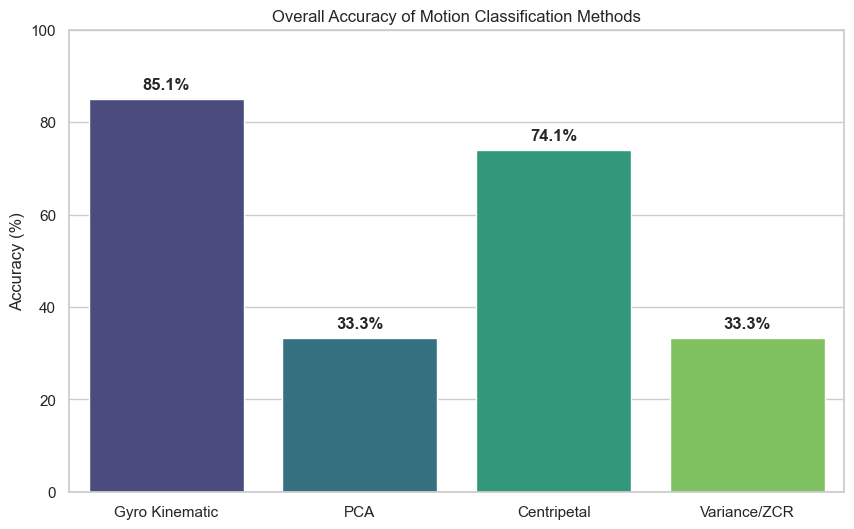

In [6]:
# Plot Accuracy
plt.figure(figsize=(10, 6))
sns.barplot(x=list(accuracy_dict.keys()), y=list(accuracy_dict.values()), palette='viridis')
plt.title("Overall Accuracy of Motion Classification Methods")
plt.ylabel("Accuracy (%)")
plt.ylim(0, 100)
for i, v in enumerate(accuracy_dict.values()):
    plt.text(i, v + 2, f"{v:.1f}%", ha='center', fontweight='bold')
plt.show()


### Detailed Confusion Matrices
Let's see where the algorithms struggle by plotting the confusion matrix for the best performing methods.


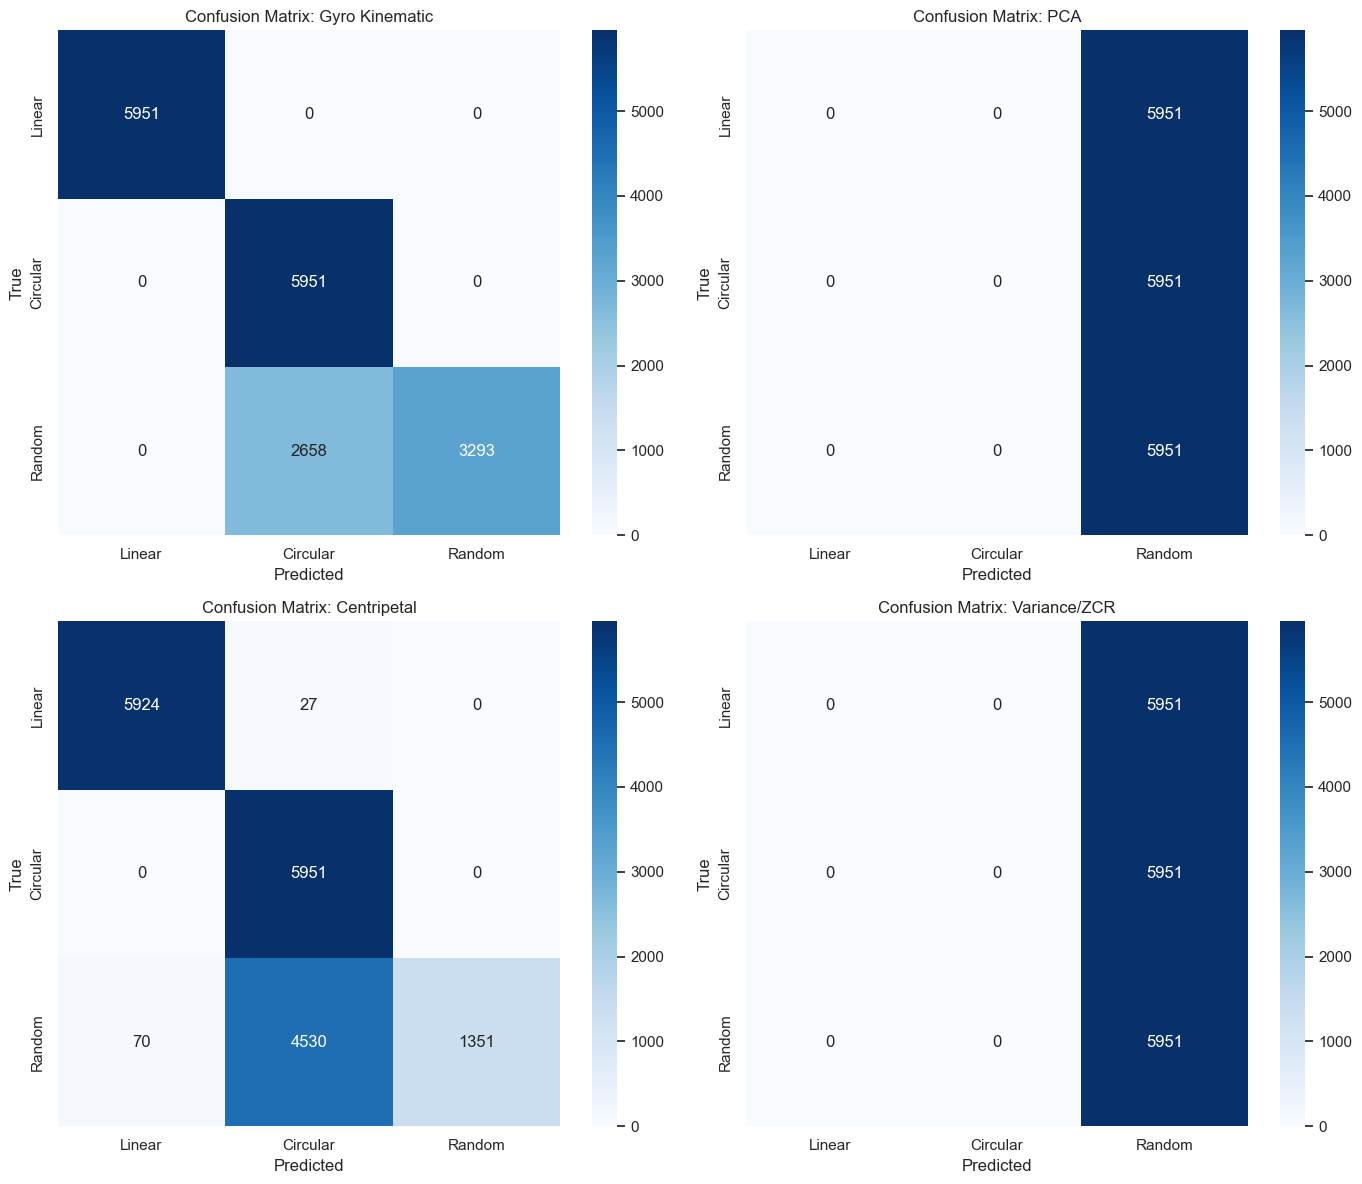

In [7]:
fig, ax = plt.subplots(2, 2, figsize=(14, 12))
ax = ax.flatten()

labels = ["Linear Motion", "Circular/Curvilinear Motion", "Random Walk"]

for i, method in enumerate(methods):
    cm = confusion_matrix(results_df['True'], results_df[method], labels=labels)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax[i], 
                xticklabels=['Linear', 'Circular', 'Random'], 
                yticklabels=['Linear', 'Circular', 'Random'])
    ax[i].set_title(f"Confusion Matrix: {method_names[i]}")
    ax[i].set_xlabel('Predicted')
    ax[i].set_ylabel('True')

plt.tight_layout()
plt.show()


## 4. Evaluation on Real Trajectories
In this section, we process real trajectory CSVs (`log_traj.csv` and `test_calss.csv`). We derive kinematics (velocity, acceleration, yaw) from position differences, simulate IMU readings, and feed them to our `IndependentMotionClassifier`. We then compare the predicted motion state vs the theoretical ground truth motion state over time.

In [ ]:
def evaluate_real_trajectory(csv_path):
    print(f"\n--- Evaluating Real Trajectory: {csv_path} ---")
    df = pd.read_csv(csv_path)
    if len(df) < 2:
        return
        
    df = df.sort_values('timestamp').reset_index(drop=True)
    t = df['timestamp'].values
    x = df['x'].values
    y = df['y'].values
    
    # Calculate kinematics
    dt_arr = np.diff(t)
    dt_arr[dt_arr == 0] = 1e-6
    
    vx = np.diff(x) / dt_arr
    vy = np.diff(y) / dt_arr
    vx = np.insert(vx, 0, vx[0])
    vy = np.insert(vy, 0, vy[0])
    
    ax = np.diff(vx) / dt_arr
    ay = np.diff(vy) / dt_arr
    ax = np.insert(ax, 0, ax[0])
    ay = np.insert(ay, 0, ay[0])
    
    yaw = np.arctan2(vy, vx)
    yaw = np.unwrap(yaw)
    w = np.diff(yaw) / dt_arr
    w = np.insert(w, 0, w[0])
    
    methods = [
        "Method 1: Gyro Kinematic",
        "Method 2: PCA",
        "Method 3: Centripetal",
        "Method 4: Variance/ZCR"
    ]
    
    sim = IMUSimulator(sample_rate=100, acc_noise_std=0.05, gyro_noise_std=0.01)
    
    results = {m: {'t': [], 'y_true': [], 'y_pred': []} for m in methods}
    classifiers = {m: IndependentMotionClassifier() for m in methods}
    tags = {m: TagMock() for m in methods}
    
    for i in range(len(t)):
        if i == 0: continue
        dt = t[i] - t[i-1]
        if dt <= 0: continue
        
        pos = Position(x[i], y[i], 0.0)
        vel_world = np.array([vx[i], vy[i], 0.0])
        accel_world = np.array([ax[i], ay[i], 0.0])
        angular_vel_world = np.array([0, 0, w[i]])
        
        acc_meas, gyro_meas = sim.generate_imu_data(
            pos, yaw[i], dt, velocity=vel_world, acceleration=accel_world, angular_velocity=angular_vel_world
        )
        
        for m in methods:
            tag = tags[m]
            tag.velocity.x = vx[i]
            tag.velocity.y = vy[i]
            tag.angular_velocity = w[i]
            
            tag.imu_data.add_measurement(t[i], acc_meas[0], acc_meas[1], acc_meas[2], gyro_meas[0], gyro_meas[1], gyro_meas[2])
            
            res = classifiers[m].update(tag, selected_method=m)
            if res is not None:
                gt, pred = res
                results[m]['t'].append(t[i])
                results[m]['y_true'].append(gt)
                results[m]['y_pred'].append(pred)

    fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=True)
    fig.suptitle(f'Motion State Classification over Time\nDataset: {csv_path}')
    
    state_to_num = {"Linear Motion": 0, "Circular/Curvilinear Motion": 1, "Random Walk": 2, "Unknown": -1}
    
    for ax_idx, m in enumerate(methods):
        time_arr = results[m]['t']
        if len(time_arr) == 0:
            axes[ax_idx].set_title(f"{m} - Not enough data")
            continue
            
        y_true = [state_to_num.get(s, -1) for s in results[m]['y_true']]
        y_pred = [state_to_num.get(s, -1) for s in results[m]['y_pred']]
        
        axes[ax_idx].step(time_arr, y_true, label='Ground Truth', where='post', linewidth=2, linestyle='--')
        axes[ax_idx].step(time_arr, y_pred, label='Predicted', where='post', linewidth=2, alpha=0.7)
        axes[ax_idx].set_yticks([0, 1, 2])
        axes[ax_idx].set_yticklabels(["Linear", "Circular", "Random"])
        axes[ax_idx].set_ylabel("State")
        axes[ax_idx].set_title(f"{m} (Accuracy: {accuracy_score(y_true, y_pred):.2f})")
        axes[ax_idx].legend(loc='upper right')
        
    plt.xlabel('Time (s)')
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

# Evaluate on specific trajectories
evaluate_real_trajectory('data/trajectories/log_traj.csv')
evaluate_real_trajectory('data/trajectories/test_calss.csv')